# Problem Statement
- Predict house prices based on factors such as location, area, number of bedrooms, bathrooms, and other property features.
- Build a machine learning model that accurately predicts the expected price of a house from these features.

### Import Required Packages

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

### load the dataset

In [2]:
df = pd.read_csv('./modified_data.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


### EDA

In [3]:
df[['street']].head()

,street
0,18810 Densmore Ave N
1,709 W Blaine St
2,26206-26214 143rd Ave SE
3,857 170th Pl NE
4,9105 170th Ave NE


In [4]:
df['street'].value_counts().head(20)

street
2520 Mulberry Walk NE      4
2500 Mulberry Walk NE      3
Burke-Gilman Trail         2
23017 SE 281st Ct          2
35229 SE Terrace St        2
13800 453rd Ave SE         2
9126 45th Ave SW           2
1273 NE Hickory Ln         2
17122 NE 117th St          2
4313 SW Willow St          2
12303 Sand Point Way NE    2
513 N 46th St              2
24345 35th Pl S            2
4924 SE 2nd Pl             2
2050 14th Ave W            2
9507 Ashworth Ave N        2
820 NW 95th St             2
106 24th Ave E             2
9413 34th Ave SW           2
Indian Trail               2
Name: count, dtype: int64

In [5]:
print("Total streets:", df['street'].nunique())
print("Total rows:", len(df))

street_counts = df['street'].value_counts()

print("Streets appearing once:", (street_counts == 1).sum())
print("Streets appearing more than once:", (street_counts > 1).sum())

Total streets: 4525
Total rows: 4600
Streets appearing once: 4453
Streets appearing more than once: 72


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   str    
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   str    
 15  city            4600 non-null   str    
 16  statezip        4600 non-null   str    
 17  price_per_sqft  4600 non-null   float64
dtyp

In [7]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,265.876209
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,357.503362
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,180.817500
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,243.855000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,314.840000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,22533.900000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
print("date:", df['date'].nunique())
print("street:", df['street'].nunique())
print("city:", df['city'].nunique())
print("statezip:", df['statezip'].nunique())

date: 70
street: 4525
city: 44
statezip: 77


In [10]:
df.drop('street', axis=1, inplace=True)

In [11]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

city_encoded = encoder.fit_transform(df[['city']])

city_df = pd.DataFrame(
    city_encoded,
    columns=encoder.get_feature_names_out(['city'])
)

df = pd.concat([df, city_df], axis=1)

df.drop('city', axis=1, inplace=True)

In [12]:
statezip_encoded = encoder.fit_transform(df[['statezip']])

statezip_df = pd.DataFrame(
    statezip_encoded,
    columns=encoder.get_feature_names_out(['statezip'])
)

df = pd.concat([df, statezip_df], axis=1)

df.drop('statezip', axis=1, inplace=True)

In [13]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

df.drop('date', axis=1, inplace=True)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Columns: 137 entries, price to month
dtypes: float64(126), int32(2), int64(9)
memory usage: 4.8 MB


In [15]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354,year,month
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2014,5
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2014,5
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2014,5
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2014,5
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2014,5


In [16]:
df.corr(numeric_only=True)['price']

price                1.000000
bedrooms             0.200336
bathrooms            0.327110
sqft_living          0.430410
sqft_lot             0.050451
                       ...   
statezip_WA 98199    0.084996
statezip_WA 98288   -0.014453
statezip_WA 98354   -0.009876
year                      NaN
month                0.041081
Name: price, Length: 137, dtype: float64

In [17]:
df.corr(numeric_only=True)['price'] \
    .drop('price') \
    .abs() \
    .sort_values(ascending=False)

price_per_sqft          0.819279
sqft_living             0.430410
sqft_above              0.367570
bathrooms               0.327110
view                    0.228504
                          ...   
statezip_WA 98068       0.000705
city_Snoqualmie Pass    0.000705
city_Preston            0.000388
statezip_WA 98050       0.000388
year                         NaN
Name: price, Length: 136, dtype: float64

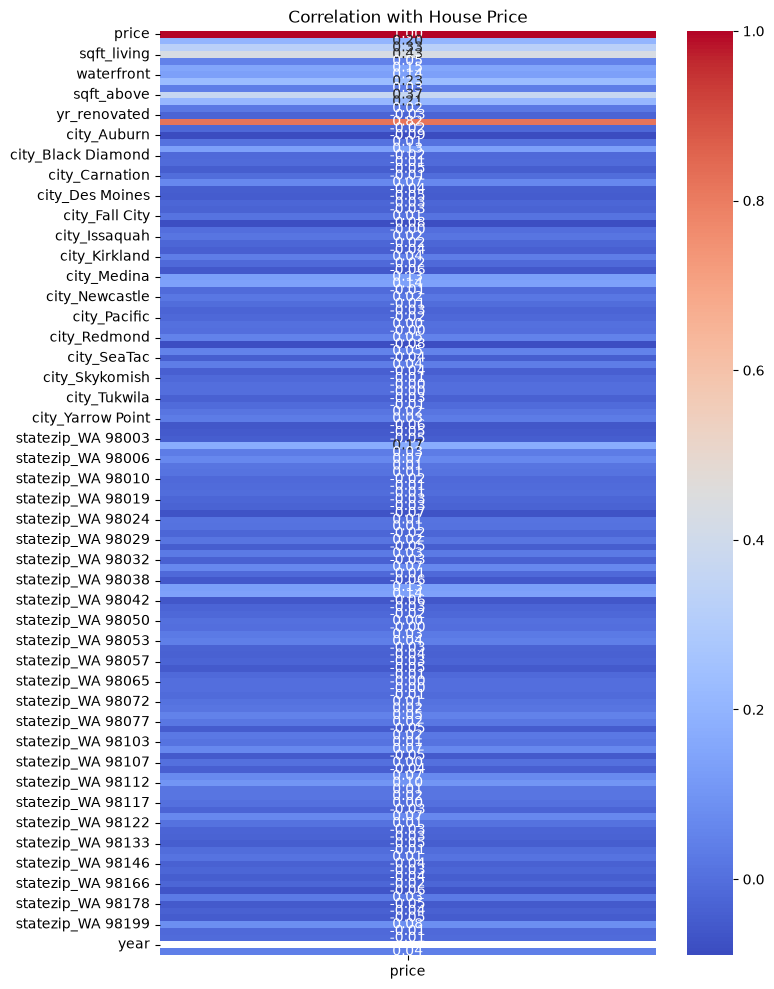

In [18]:
price_corr = df.corr(numeric_only=True)[['price']]

plt.figure(figsize=(8, 12))

sns.heatmap(
    price_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation with House Price')
plt.show()

In [19]:
df.drop('price_per_sqft', axis=1, inplace=True)

In [20]:
df.drop('year', axis=1, inplace=True)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Columns: 135 entries, price to month
dtypes: float64(125), int32(1), int64(9)
memory usage: 4.7 MB


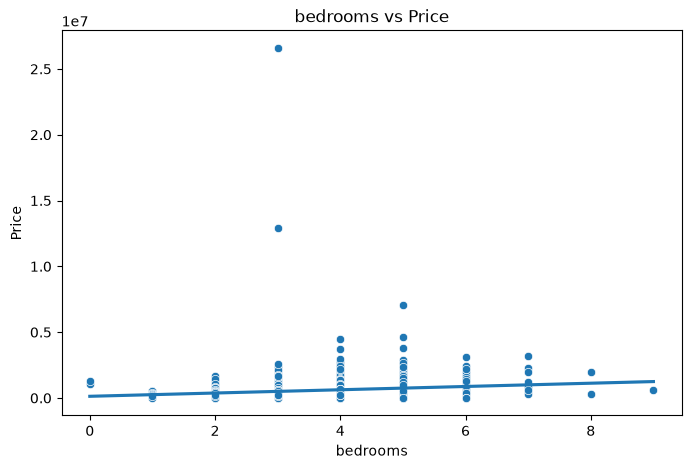

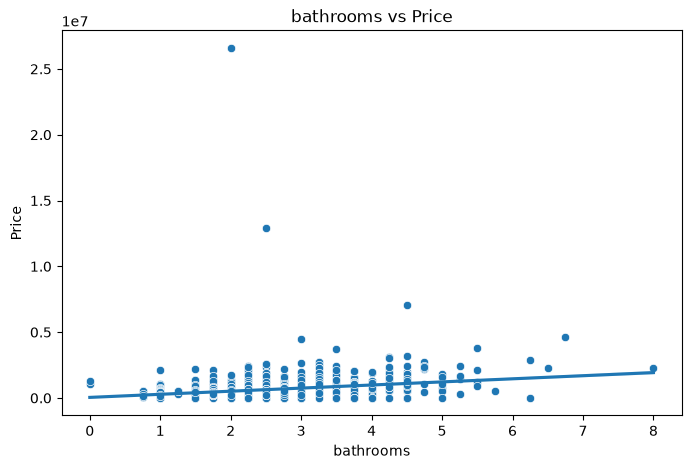

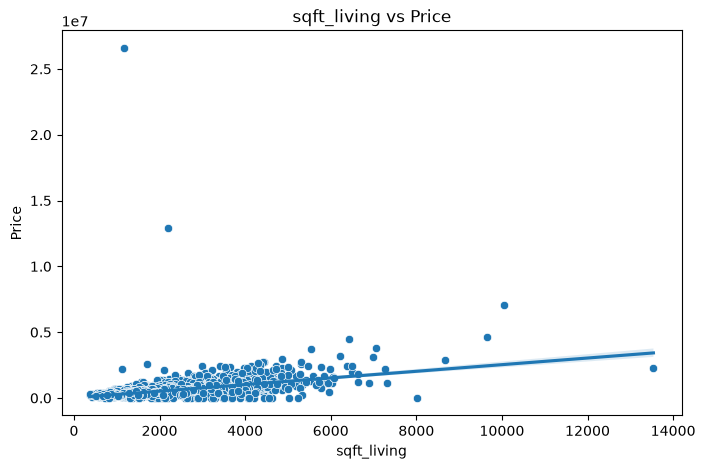

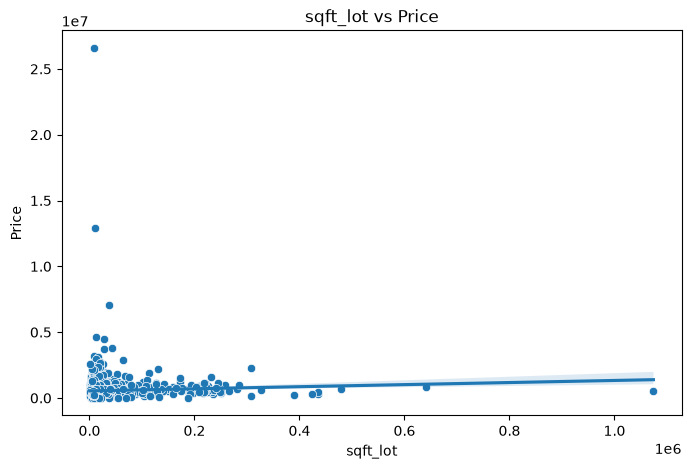

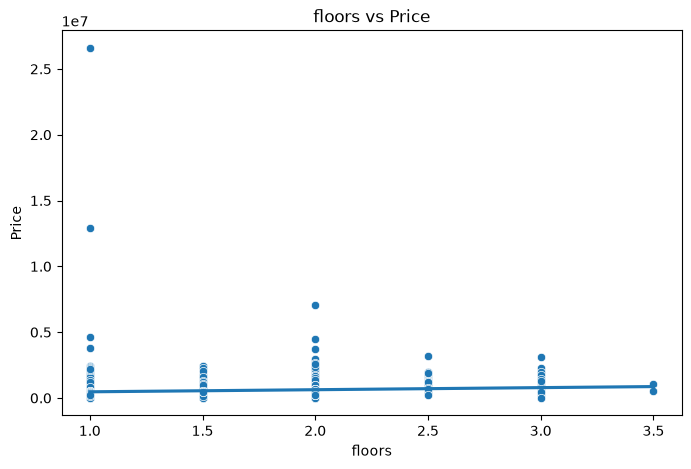

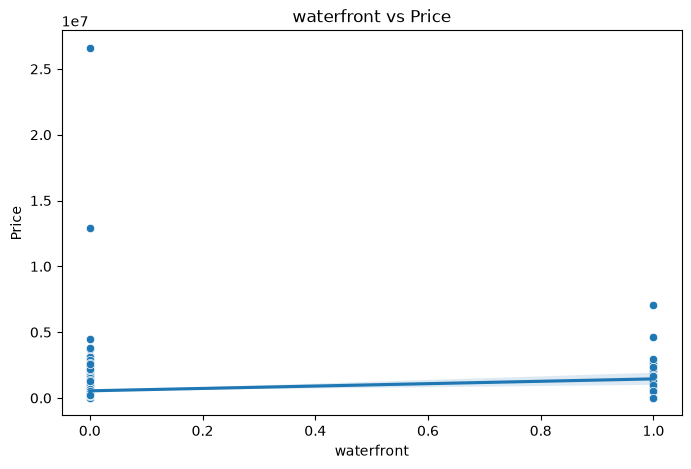

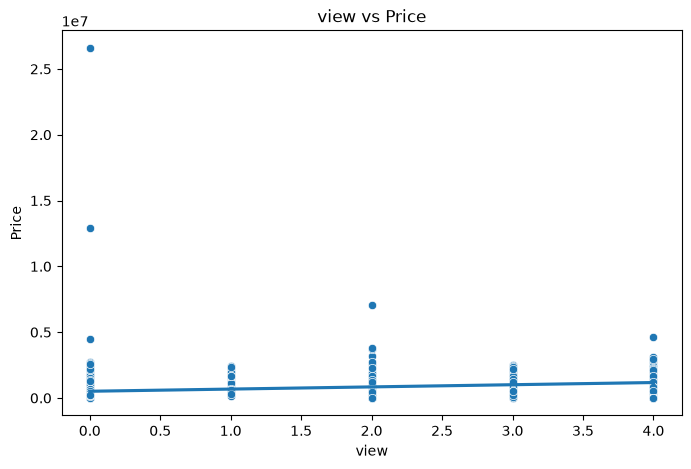

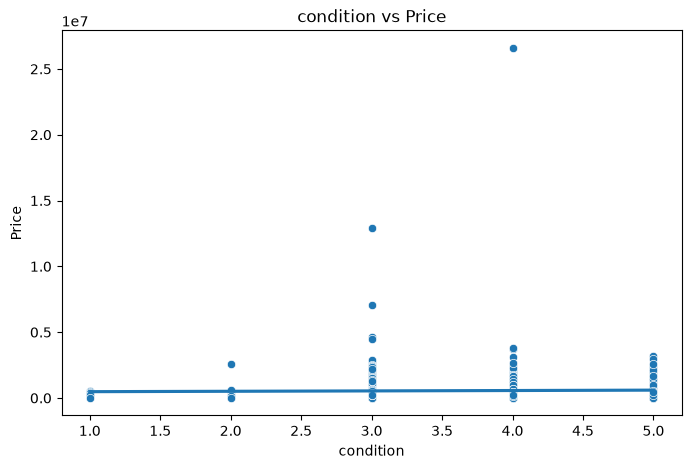

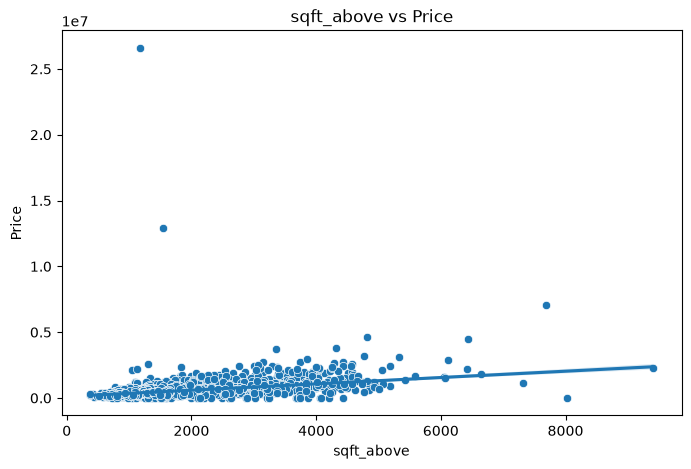

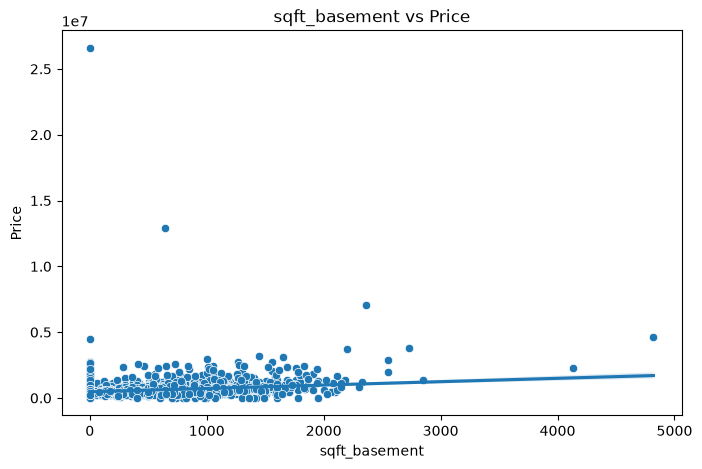

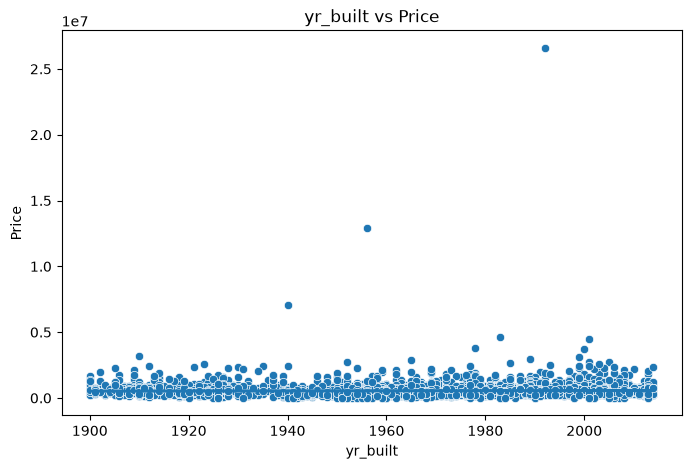

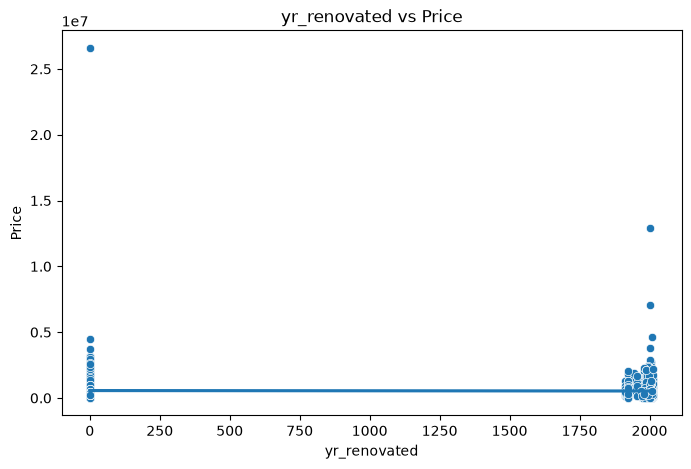

In [22]:
features = [
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'floors',
    'waterfront',
    'view',
    'condition',
    'sqft_above',
    'sqft_basement',
    'yr_built',
    'yr_renovated'
]

for feature in features:

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x=feature,
        y='price'
    )

    sns.regplot(
        data=df,
        x=feature,
        y='price',
        scatter=False
    )

    plt.title(f'{feature} vs Price')
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.show()

### split the data

In [23]:
x = df.drop('price', axis=1)
y = df['price']

In [24]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.7,random_state=42 )

### Train The Model

In [25]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [26]:
model.fit(x, y)
y_pred = model.predict(x_train)

### Evaluate The Model

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 42600.01762139752
MSE : 13103542196.463106
RMSE: 114470.70453379373
R2  : 0.909199054070879


In [28]:
# predict on testing data
y_pred_test = model.predict(x_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_test)

mse = mean_squared_error(y_test, y_pred_test)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_test)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 57465.00547780194
MSE : 94376843928.84933
RMSE: 307208.1443074863
R2  : 0.8693659287292761


In [29]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

print("Training R2:", r2_score(y_train, train_pred))
print("Testing R2 :", r2_score(y_test, test_pred))

Training R2: 0.909199054070879
Testing R2 : 0.8693659287292761


### Inference the model

In [30]:
new_house = x.iloc[[0]].copy()

In [31]:
prediction = model.predict(new_house)

print("Predicted House Price:", prediction[0])

Predicted House Price: 312719.95


In [36]:
num= int(input("Enter a numer"))

if num % 2 == 0:
    print("The number is even.")
else:
    print("The Number Is Odd")


The Number Is Odd


In [37]:
num1 = int(input("Enter First Number : "))
num2 = int(input("Enter Second Number : "))

num3 = num1 + num2
print(num3)

50


In [38]:
def add(a,b):
    return a + b

add(6,8)

14

In [42]:
l = [2,3,4,5,6,7,8,9]

odd = [i for i in l if i % 2 != 0]
print(odd)

[3, 5, 7, 9]


In [ ]:
name = "vikas"

a = ""

for